In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
len(df.columns)

21

In [6]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [7]:
df.shape

(7043, 21)

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


<Axes: >

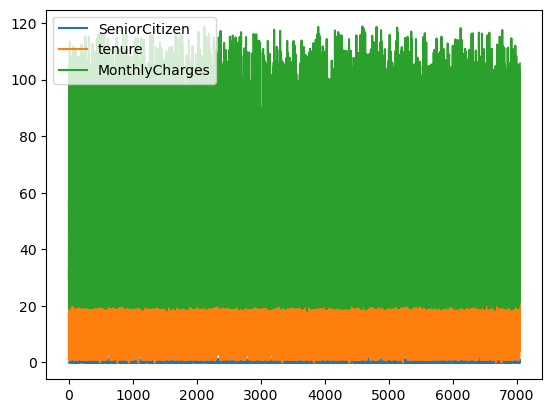

In [13]:
df.plot()

<Axes: ylabel='MonthlyCharges'>

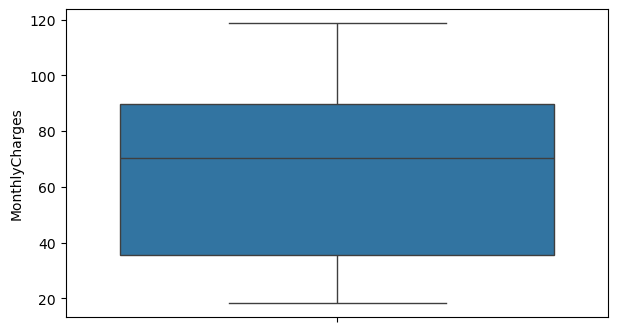

In [14]:
plt.figure(figsize=(7,4))
sns.boxplot(y=df['MonthlyCharges'])

In [15]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()

np.int64(11)

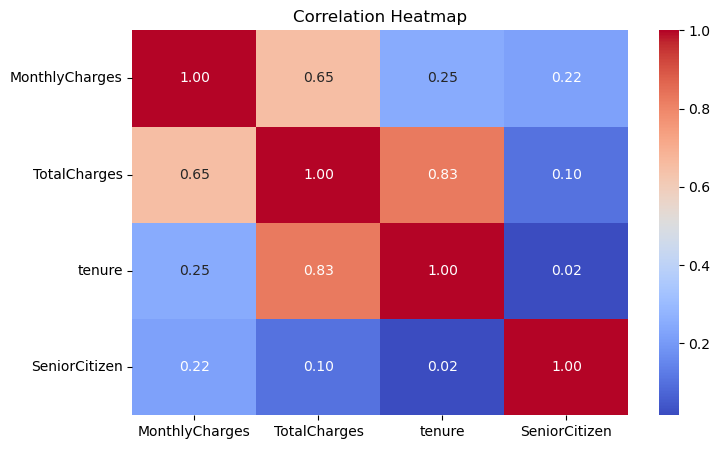

In [16]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['MonthlyCharges','TotalCharges', 'tenure','SeniorCitizen']].corr(),
           annot=True, fmt='0.2f', cmap='coolwarm')
plt.title('Correlation Heatmap', fontsize=12)
plt.show()

<Axes: >

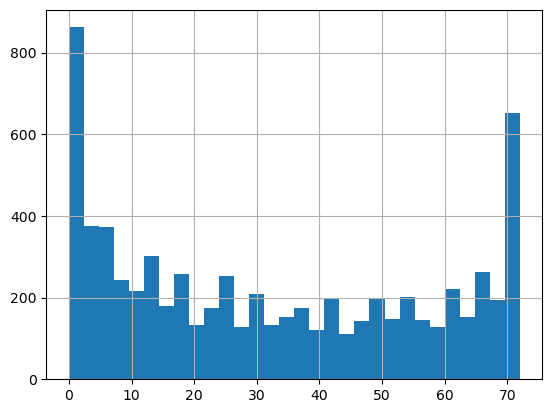

In [17]:
df['tenure'].hist(bins=30)

In [18]:
#checking for outliers for monthly charges
Q1=df['MonthlyCharges'].quantile(0.25)
Q3=df['MonthlyCharges'].quantile(0.75)
IQR= Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers = df[(df['MonthlyCharges']<lower_bound) | (df['MonthlyCharges']>upper_bound)]

outliers.shape

(0, 21)

In [19]:
#capping outliers (nothing gets capped if there are no outliers)
df['MonthlyCharges'] = df['MonthlyCharges'].clip(upper=upper_bound)
df[['MonthlyCharges']].describe()

,MonthlyCharges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [20]:
#checking the zscore for monthlycharges
df['zscore'] = stats.zscore(df['MonthlyCharges'])
outliers= df[df['zscore'].abs()>3]

outliers.shape

(0, 22)

In [21]:
#checking for outliers for tenure
Q1=df['tenure'].quantile(0.25)
Q3=df['tenure'].quantile(0.75)
IQR= Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers_1 = df[(df['tenure']<lower_bound) | (df['tenure']>upper_bound)]

outliers_1.shape

(0, 22)

In [22]:
#capping outliers (nothing gets capped if there are no outliers)
df['tenure'] = df['tenure'].clip(upper=upper_bound)
df[['tenure']].describe()

,tenure
count,7043.000000
mean,32.371149
std,24.559481
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


In [23]:
#checking the zscore for tenure
df['zscore'] = stats.zscore(df['tenure'])
outliers_1= df[df['zscore'].abs()>3]

#removing the zscore column since we are done with it
df = df.drop(columns='zscore')

outliers_1.shape

(0, 22)

<Axes: >

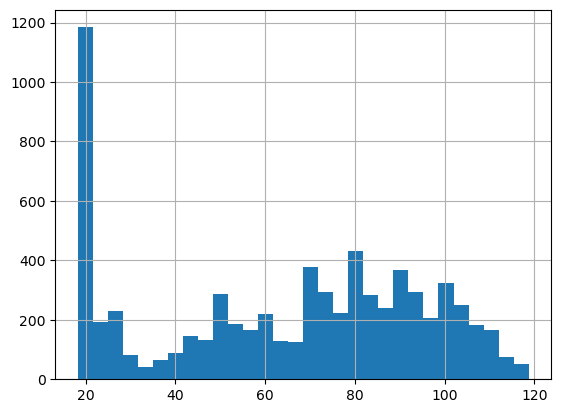

In [24]:
#histogramplot for MonthlyCharges
df['MonthlyCharges'].hist(bins=30)

<Axes: >

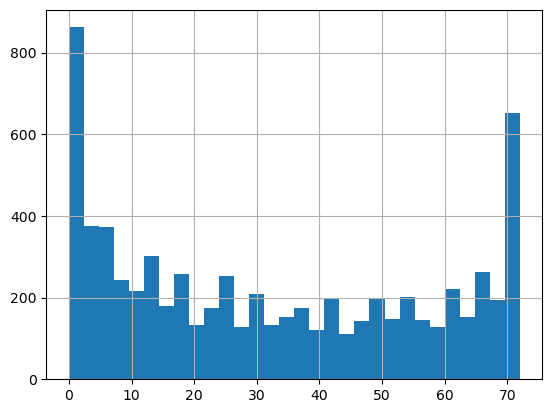

In [25]:
#histogramplot for tenure
df['tenure'].hist(bins=30)

<Axes: xlabel='Contract', ylabel='count'>

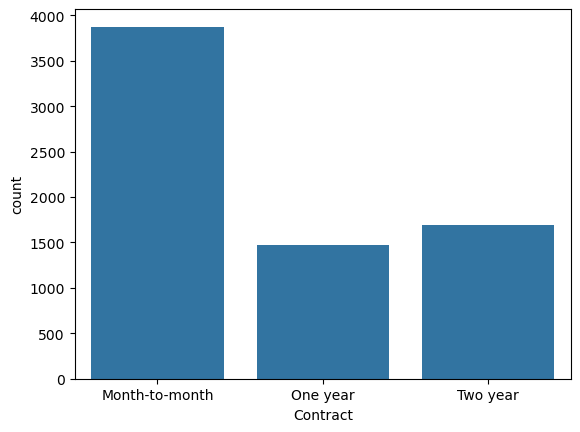

In [26]:
sns.countplot(x='Contract', data=df)

<Axes: xlabel='Contract', ylabel='count'>

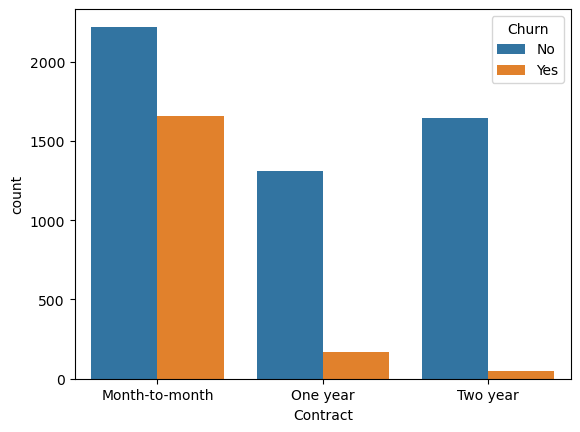

In [27]:
sns.countplot(x='Contract', hue='Churn', data=df)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

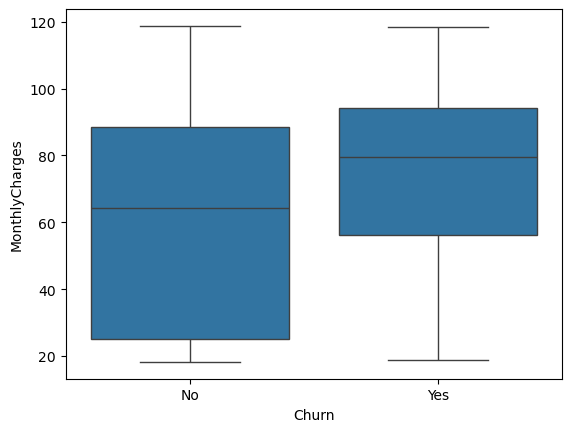

In [28]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

<Axes: xlabel='Churn', ylabel='tenure'>

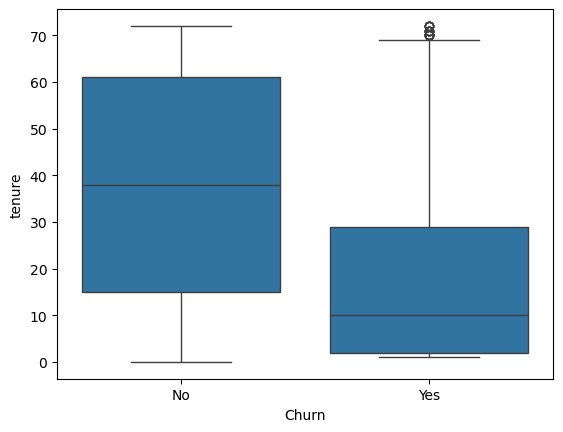

In [29]:
sns.boxplot(x='Churn', y='tenure', data=df)

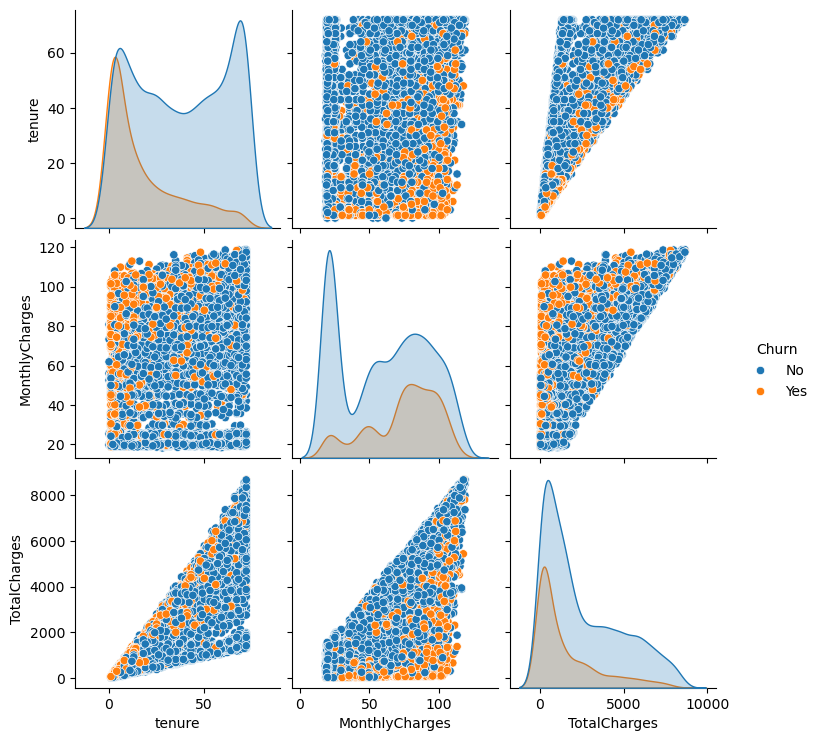

In [30]:
sns.pairplot(df[['tenure','MonthlyCharges','TotalCharges','Churn']], hue='Churn')

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


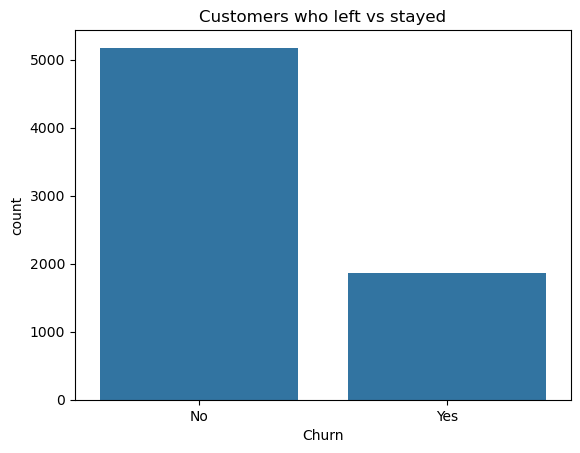

In [31]:
#churn vs not churning (counts and percentages)
print(df['Churn'].value_counts())
print((df['Churn'].value_counts(normalize=True)*100).round(1))

sns.countplot(x='Churn', data=df)
plt.title('Customers who left vs stayed')
plt.show()

In [32]:
#churn rate (%) for the main groups
for col in ['Contract','InternetService','PaymentMethod','TechSupport','OnlineSecurity']:
    rate = df.groupby(col)['Churn'].apply(lambda s: (s=='Yes').mean()*100).round(1)
    print(rate, '\n')

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64 

InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn, dtype: float64 

PaymentMethod
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Electronic check             45.3
Mailed check                 19.1
Name: Churn, dtype: float64 

TechSupport
No                     41.6
No internet service     7.4
Yes                    15.2
Name: Churn, dtype: float64 

OnlineSecurity
No                     41.8
No internet service     7.4
Yes                    14.6
Name: Churn, dtype: float64 



In [33]:
#step 1: getting the data ready
model_df = pd.read_csv('Telco-Customer-Churn.csv')

#fixing TotalCharges (it was text before)
model_df['TotalCharges'] = pd.to_numeric(model_df['TotalCharges'], errors='coerce')

#turning Churn into numbers: Yes = 1, No = 0
model_df['Churn'] = model_df['Churn'].map({'Yes': 1, 'No': 0})

#X = the information, y = what we want to predict
X = model_df.drop(columns=['Churn', 'customerID'])
y = model_df['Churn']

In [34]:
#step 2: split into train and test
#80% to teach the model, 20% to test it
#stratify keeps the churn ratio the same in both parts
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Train rows:', X_train.shape[0])
print('Test rows:', X_test.shape[0])

Train rows: 5634
Test rows: 1409


In [35]:
#step 3: set up the cleaning steps
#separating number columns from text columns
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(exclude='number').columns

#numbers: fill blanks with the median, then scale
num_steps = Pipeline([
    ('fill', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())])

#text: fill blanks with the most common value, then turn into 0/1 columns
cat_steps = Pipeline([
    ('fill', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore'))])

#putting both together
preprocessor = ColumnTransformer([
    ('num', num_steps, num_cols),
    ('cat', cat_steps, cat_cols)])

In [36]:
#step 4: build and train the two models
#model 1: Logistic Regression
log_model = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))])

#model 2: Random Forest
rf_model = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=300, random_state=42,
                                     class_weight='balanced', n_jobs=-1))])

#training both
log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [37]:
#step 5: compare the models
#a small function that scores any model
def score_model(name, model):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    return {'Model': name,
            'Accuracy': accuracy_score(y_test, preds),
            'Precision': precision_score(y_test, preds),
            'Recall': recall_score(y_test, preds),
            'F1': f1_score(y_test, preds),
            'ROC AUC': roc_auc_score(y_test, probs)}

results_df = pd.DataFrame([
    score_model('Logistic Regression', log_model),
    score_model('Random Forest', rf_model)]).set_index('Model').round(3)

results_df

,Accuracy,Precision,Recall,F1,ROC AUC
Model,,,,,
Logistic Regression,0.738,0.504,0.783,0.614,0.841
Random Forest,0.781,0.617,0.465,0.530,0.822


In [38]:
#step 6: save the file for the dashboard
#churn chance for every customer
model_df['Churn_Probability'] = log_model.predict_proba(X)[:, 1].round(3)

#grouping customers into risk levels
model_df['Risk_Level'] = pd.cut(model_df['Churn_Probability'],
                                bins=[0, 0.4, 0.7, 1],
                                labels=['Low', 'Medium', 'High'],
                                include_lowest=True)

#turning Churn back into words so it reads well in the dashboard
model_df['Churn_Label'] = model_df['Churn'].map({1: 'Yes', 0: 'No'})

#saving the file to load into Power BI
model_df.to_csv('churn_dashboard_data.csv', index=False)
model_df['Risk_Level'].value_counts()

Risk_Level
Low       3598
High      1782
Medium    1663
Name: count, dtype: int64